In [1]:
import os, glob, warnings, gc, random
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_everything(SEED)

DEVICE = torch.device('cpu')

## 1. Cấu hình

In [2]:
SYNTHETIC_DATA = False
DAPT_BASE = '/kaggle/input/datasets/sowmyamyneni/dapt2020/csv'
DAPT_CSV_PATHS = {
    1: [f'{DAPT_BASE}/enp0s3-monday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-monday-pvt.pcap_Flow.csv'],
    2: [f'{DAPT_BASE}/enp0s3-public-tuesday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-pvt-tuesday.pcap_Flow.csv'],
    3: [f'{DAPT_BASE}/enp0s3-public-wednesday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-pvt-wednesday.pcap_Flow.csv'],
    4: [f'{DAPT_BASE}/enp0s3-public-thursday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-pvt-thursday.pcap_Flow.csv'],
    5: [f'{DAPT_BASE}/enp0s3-tcpdump-friday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-tcpdump-pvt-friday.pcap_Flow.csv'],
}
DAPT_LABEL_COL = 'Label'

ATTACK_TO_PHASE = {
    # Phase 0 — Benign
    'Benign': 0, 'benign': 0, 'BENIGN': 0, 'Normal': 0, 'normal': 0,
    # Phase 1 — Reconnaissance
    'Network Scan': 1, 'NetworkScan': 1, 'network scan': 1,
    'Web vulnerability Scan': 1, 'Web Vulnerability Scan': 1,
    'WebVulnerabilityScan': 1, 'Port Scan': 1, 'PortScan': 1,
    'Reconnaissance': 1,
    # Phase 2 — Foothold
    'SQL injection': 2, 'SQL Injection': 2, 'SQLInjection': 2,
    'Backdoor': 2, 'backdoor': 2,
    'Malware Download': 2, 'MalwareDownload': 2,
    'Command Injection': 2, 'CommandInjection': 2,
    'CSRF': 2, 'csrf': 2,
    'Account brute force': 2, 'AccountBruteForce': 2, 'BruteForce': 2,
    'Foothold': 2,
    # Phase 3 — Lateral Movement
    'DoS': 3, 'dos': 3, 'DenialOfService': 3,
    'Privilege escalation': 3, 'PrivilegeEscalation': 3,
    'Lateral Movement': 3, 'LateralMovement': 3,
    # Phase 4 — Exfiltration
    'Data Exfiltration': 4, 'DataExfiltration': 4,
    'Exfiltration': 4, 'exfiltration': 4,
}
APT_PHASE_NAMES = [
    'Benign', 'Reconnaissance', 'Foothold', 'Lateral Movement', 'Exfiltration'
]
N_APT_PHASES = len(APT_PHASE_NAMES)

N_PCA       = 20
N_BINS      = 32
BATCH_SIZE  = 1024
NUM_WORKERS = 4
EPOCHS      = 5
LR          = 1e-3
D_MODEL     = 64
N_HEADS     = 4
N_PERSIST   = 4
LMM_HIDDEN  = 128
SWA_WINDOW  = 16
LMM_LAYERS  = 2    
OUTLIER_TH  = 3.0
PRE_BATCH   = 50_000

# Synthetic-only params
N_SYNTHETIC = 5000
N_FEATURES  = 40

print(f'Mode : {"SYNTHETIC" if SYNTHETIC_DATA else "REAL DAPT 2020 (sowmyamyneni/dapt2020)"}')
print(f'Phases: {N_APT_PHASES} | D_MODEL={D_MODEL} | Epochs={EPOCHS}')
if not SYNTHETIC_DATA:
    for day, paths in DAPT_CSV_PATHS.items():
        for path in paths:
            status = '✅' if os.path.exists(path) else '❌'
            print(f'  Day {day}: {os.path.basename(path)} {status}')


Mode : REAL DAPT 2020 (sowmyamyneni/dapt2020)
Phases: 5 | D_MODEL=64 | Epochs=5
  Day 1: enp0s3-monday.pcap_Flow.csv ✅
  Day 1: enp0s3-monday-pvt.pcap_Flow.csv ✅
  Day 2: enp0s3-public-tuesday.pcap_Flow.csv ✅
  Day 2: enp0s3-pvt-tuesday.pcap_Flow.csv ✅
  Day 3: enp0s3-public-wednesday.pcap_Flow.csv ✅
  Day 3: enp0s3-pvt-wednesday.pcap_Flow.csv ✅
  Day 4: enp0s3-public-thursday.pcap_Flow.csv ✅
  Day 4: enp0s3-pvt-thursday.pcap_Flow.csv ✅
  Day 5: enp0s3-tcpdump-friday.pcap_Flow.csv ✅
  Day 5: enp0s3-tcpdump-pvt-friday.pcap_Flow.csv ✅


## 2. Load dữ liệu DAPT 2020

In [3]:
def generate_synthetic_dapt(n_per_phase=1000, n_features=40, seed=42):
    np.random.seed(seed)
    dfs = []
    configs = [
        (0.3, 0.1, []),
        (0.5, 0.3, [0, 1, 2]),
        (0.6, 0.4, [5, 6, 7]),
        (0.7, 0.3, [10, 11]),
        (0.9, 0.5, [15, 16]),
    ]
    for phase_id, (mu, sigma, skew) in enumerate(configs):
        data = np.abs(np.random.randn(n_per_phase, n_features) * sigma + mu)
        for f in skew:
            data[:, f] += np.random.exponential(2.0, n_per_phase)
        df_p = pd.DataFrame(data, columns=[f'f{i}' for i in range(n_features)])
        df_p['APT_Phase'] = phase_id
        dfs.append(df_p)
    return pd.concat(dfs, ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)


def load_real_dapt(csv_paths, attack_to_phase, label_col_hint='Stage'):
    all_files = []
    for day, paths in csv_paths.items():
        if not isinstance(paths, list):
            paths = [paths]
        for path in paths:
            if os.path.exists(path):
                all_files.append((day, path))
            else:
                print(f'  [Day {day}]  Không tìm thấy, bỏ qua: {path}')

    if not all_files:
        raise FileNotFoundError(f'Không tìm thấy bất kỳ file CSV nào tại: {DAPT_BASE}')

    standard_cols = None
    for day, path in all_files:
        with open(path, 'r', errors='ignore') as f:
            first_line = f.readline()
        has_header = any(h in first_line.lower() for h in ["flow id", "flow_id", "src ip", "src_ip", "protocol", "timestamp"])
        if has_header:
            df_temp = pd.read_csv(path, nrows=5)
            standard_cols = list(df_temp.columns)
            print(f'  -> Lấy bộ cột chuẩn từ file có header: {os.path.basename(path)} ({len(standard_cols)} cột)')
            break

    if standard_cols is None:
        raise ValueError("Không tìm thấy file nào có header để lấy danh sách cột chuẩn!")

    dfs = []
    for day, path in all_files:
        with open(path, 'r', errors='ignore') as f:
            first_line = f.readline()
        has_header = any(h in first_line.lower() for h in ["flow id", "flow_id", "src ip", "src_ip", "protocol", "timestamp"])

        print(f'Loading Day {day}: {os.path.basename(path)} (Has Header: {has_header}) ...')
        try:
            if has_header:
                df_d = pd.read_csv(path, low_memory=False)
                # Đảm bảo giữ đúng số lượng và thứ tự cột chuẩn
                df_d = df_d.reindex(columns=standard_cols)
            else:
                # File không có header -> dùng standard_cols
                df_d = pd.read_csv(path, header=None, names=standard_cols, low_memory=False)
            
            df_d['Day'] = day
            dfs.append(df_d)
        except Exception as e:
            print(f'  Lỗi khi đọc file {os.path.basename(path)}: {e}')

    if not dfs:
        raise ValueError("Không load được dataframe nào.")

    df = pd.concat(dfs, ignore_index=True)
    print(f'Concat shape: {df.shape}')

    # Bước 4: Xác định cột nhãn (Stage hoặc Activity)
    label_col = None
    search_cols = []
    if label_col_hint:
        search_cols.append(label_col_hint)
    search_cols.extend(['Stage', 'stage', 'Activity', 'activity', 'Label', 'label', 'Attack', 'attack', 'Class', 'Category'])
    
    for c in search_cols:
        if c in df.columns:
            label_col = c
            break

    if label_col is None:
        raise ValueError(f'Không tìm thấy cột nhãn. Cột hiện có: {list(df.columns)}')
    print(f'Cột nhãn được chọn: "{label_col}"')

    for lbl in sorted(df[label_col].dropna().unique()):
        print(f'  "{lbl}": {(df[label_col]==lbl).sum():,}')

    df['APT_Phase'] = df[label_col].astype(str).map(attack_to_phase)
    unmapped = df['APT_Phase'].isna()
    if unmapped.any():
        print(f' {unmapped.sum():,} rows unmapped → fallback theo Day')
        df.loc[unmapped, 'APT_Phase'] = df.loc[unmapped, 'Day'].map({1:0, 2:1, 3:2, 4:3, 5:4})
    df['APT_Phase'] = df['APT_Phase'].fillna(0).astype(int)

    for i, name in enumerate(APT_PHASE_NAMES):
        cnt = (df['APT_Phase']==i).sum()
        print(f'  Phase {i} ({name:<22}): {cnt:>10,} ({cnt/len(df)*100:5.1f}%)')
    
    return df, label_col


if SYNTHETIC_DATA:
    print(' Synthetic Mode')
    df = generate_synthetic_dapt(N_SYNTHETIC // N_APT_PHASES, N_FEATURES)
    feature_cols = [c for c in df.columns if c != 'APT_Phase']
else:
    print(' Real DAPT 2020')
    df, _lc = load_real_dapt(DAPT_CSV_PATHS, ATTACK_TO_PHASE, DAPT_LABEL_COL)
    drop = {'APT_Phase', 'Day', _lc, 'Label', 'label', 'Attack', 'attack', 'Class', 'Category'}
    const_cols = set(df.std(numeric_only=True).pipe(lambda s: s[s==0]).index)
    feature_cols = [c for c in df.columns
                    if c not in drop | const_cols
                    and pd.api.types.is_numeric_dtype(df[c])]
    print(f'Feature cols: {len(feature_cols)}')

X_raw = df[feature_cols].values.astype(np.float32)
y_raw = df['APT_Phase'].values.astype(np.int64)
print(f'\nX={X_raw.shape} | y={y_raw.shape} | Classes={N_APT_PHASES}')


 Real DAPT 2020
  -> Lấy bộ cột chuẩn từ file có header: enp0s3-monday.pcap_Flow.csv (85 cột)
Loading Day 1: enp0s3-monday.pcap_Flow.csv (Has Header: True) ...
Loading Day 1: enp0s3-monday-pvt.pcap_Flow.csv (Has Header: True) ...
Loading Day 2: enp0s3-public-tuesday.pcap_Flow.csv (Has Header: True) ...
Loading Day 2: enp0s3-pvt-tuesday.pcap_Flow.csv (Has Header: True) ...
Loading Day 3: enp0s3-public-wednesday.pcap_Flow.csv (Has Header: True) ...
Loading Day 3: enp0s3-pvt-wednesday.pcap_Flow.csv (Has Header: True) ...
Loading Day 4: enp0s3-public-thursday.pcap_Flow.csv (Has Header: True) ...
Loading Day 4: enp0s3-pvt-thursday.pcap_Flow.csv (Has Header: False) ...
Loading Day 5: enp0s3-tcpdump-friday.pcap_Flow.csv (Has Header: True) ...
Loading Day 5: enp0s3-tcpdump-pvt-friday.pcap_Flow.csv (Has Header: True) ...
Concat shape: (86691, 86)
Cột nhãn được chọn: "Stage"
  "BENIGN": 19,454
  "Benign": 44,258
  "Data Exfiltration": 15
  "Establish Foothold": 8,604
  "Lateral Movement": 2,451


## 3. Train / Val / Test Split

In [4]:
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_raw, y_raw, test_size=0.3, stratify=y_raw, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=2/3, stratify=y_tmp, random_state=SEED)
del X_raw, X_tmp, y_tmp; gc.collect()


0

## 4. Robust Preprocessing → PCA → StandardScaler → KBins Tokenize

In [5]:
def robust_clean(X_tr, X_val, X_te, batch=50_000, th=3.0):
    for arr in [X_tr, X_val, X_te]:
        if hasattr(arr, 'values'): arr = arr.values
    X_tr  = X_tr.astype(np.float32)
    X_val = X_val.astype(np.float32)
    X_te  = X_te.astype(np.float32)

    s = min(100_000, len(X_tr))
    idx = np.random.choice(len(X_tr), s, replace=False)
    med = np.nanmedian(X_tr[idx], axis=0)
    std = np.nanstd(X_tr[idx],    axis=0); std[std==0] = 1.0

    def clean(A):
        out = []
        for i in range(0, len(A), batch):
            B = A[i:i+batch].copy()
            B[np.isinf(B)] = np.nan
            for c in range(B.shape[1]):
                m = med[c]
                bad = np.isnan(B[:,c]) | (np.abs((B[:,c]-m)/std[c]) > th)
                B[bad, c] = m
            out.append(np.clip(B, -1e6, 1e6))
        return np.vstack(out)

    Xtr, Xva, Xte = clean(X_tr), clean(X_val), clean(X_te)
    return Xtr, Xva, Xte


X_tr, X_val, X_te = robust_clean(X_tr, X_val, X_te, PRE_BATCH, OUTLIER_TH)


nc = min(N_PCA, X_tr.shape[1])
pca = PCA(n_components=nc, random_state=SEED)
X_tr  = pca.fit_transform(X_tr)
X_val = pca.transform(X_val)
X_te  = pca.transform(X_te)
print(f'PCA: {nc} components | variance={pca.explained_variance_ratio_.sum()*100:.1f}%')


sc = StandardScaler()
X_tr  = sc.fit_transform(X_tr)
X_val = sc.transform(X_val)
X_te  = sc.transform(X_te)


kbd = KBinsDiscretizer(n_bins=N_BINS, encode='ordinal', strategy='quantile')
tok_tr  = kbd.fit_transform(X_tr).astype(np.int64)
tok_val = kbd.transform(X_val).astype(np.int64)
tok_te  = kbd.transform(X_te).astype(np.int64)

vocab = [int(max(tok_tr[:,i].max(), tok_val[:,i].max(), tok_te[:,i].max())) + 2
         for i in range(tok_tr.shape[1])]
SEQ_LEN = tok_tr.shape[1]

PCA: 20 components | variance=99.5%


## 5. Dataset & DataLoader

In [6]:
class TokenDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).long()
        self.y = torch.from_numpy(y).long()
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

kw = dict(num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))
train_loader = DataLoader(TokenDS(tok_tr,  y_tr),  BATCH_SIZE, shuffle=True,  drop_last=True,  **kw)
val_loader   = DataLoader(TokenDS(tok_val, y_val), BATCH_SIZE, shuffle=False, **kw)
test_loader  = DataLoader(TokenDS(tok_te,  y_te),  BATCH_SIZE, shuffle=False, **kw)


## 5. TITAN

In [7]:
class FeatureEmbedding(nn.Module):
    def __init__(self, vocab_sizes, d):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(v, d) for v in vocab_sizes])
        self.pos  = nn.Embedding(len(vocab_sizes), d)
        self.norm = nn.LayerNorm(d)
    def forward(self, x):
        B, L = x.shape
        h = torch.stack([self.embs[i](x[:,i]) for i in range(L)], dim=1)
        p = torch.arange(L, device=x.device).unsqueeze(0).expand(B, L)
        return self.norm(h + self.pos(p))


class DimReduceBlock(nn.Module):
   
    def __init__(self, d, latent_dim=None):
        super().__init__()
        if latent_dim is None:
            latent_dim = d // 2
        self.encoder = nn.Sequential(nn.Linear(d, latent_dim), nn.LeakyReLU(0.01))
        self.decoder = nn.Sequential(nn.Linear(latent_dim, d),  nn.LeakyReLU(0.01))
        self.norm    = nn.LayerNorm(d)
    def forward(self, x):
        return self.norm(self.decoder(self.encoder(x)))


class HiddenMLP(nn.Module):

    def __init__(self, d_model, expansion=2, dropout=0.1, num_blocks=4):
        super().__init__()
        hidden = d_model // 2  # bottleneck
        self.blocks = nn.ModuleList([
            nn.ModuleDict({
                'norm': nn.LayerNorm(d_model),
                'fc1':  nn.Linear(d_model, hidden),
                'act':  nn.LeakyReLU(0.01),
                'drop': nn.Dropout(dropout),
                'fc2':  nn.Linear(hidden, d_model),
            }) for _ in range(num_blocks)
        ])
        self.out_norm = nn.LayerNorm(d_model)
    def forward(self, x):
        for b in self.blocks:
            h = b['norm'](x)
            h = b['fc2'](b['drop'](b['act'](b['fc1'](h))))
            x = x + h
        return self.out_norm(x)
class NeuralLongTermMemory(nn.Module):
  
    def __init__(self, d, hidden=128, n_layers=2):
        super().__init__()
        layers = []
        in_dim = d
        for _ in range(n_layers - 1):
            layers += [nn.Linear(in_dim, hidden), nn.LeakyReLU(0.01)]
            in_dim  = hidden
        layers.append(nn.Linear(in_dim, d))
        self.M = nn.Sequential(*layers)   # LTM = deep MLP

        self.key   = nn.Linear(d, d)
        self.value = nn.Linear(d, d)
        self.query = nn.Linear(d, d)
        self.alpha = nn.Linear(d, 1)   # forget gate
        self.eta   = nn.Linear(d, 1)   # momentum
        self.theta = nn.Linear(d, 1)   # learning rate
        self.norm  = nn.LayerNorm(d)

    def forward(self, h):
        B, L, D = h.shape
        k = self.key(h);   v = self.value(h);   q = self.query(h)
        a = torch.sigmoid(self.alpha(h))
        e = torch.sigmoid(self.eta(h))
        t = torch.sigmoid(self.theta(h)) * 0.1
        Mt = torch.zeros(B, D, device=h.device)
        St = torch.zeros(B, D, device=h.device)
        outs = []
        for i in range(L):
            v_hat = self.M(k[:,i]) + Mt        
            St = e[:,i]*St - t[:,i]*2*(v_hat - v[:,i])   
            Mt = (1 - a[:,i])*Mt + St            
            outs.append(self.M(q[:,i]) + Mt)     
        return self.norm(torch.stack(outs, dim=1))


class SlidingWindowAttention(nn.Module):
    def __init__(self, d, n_heads, window=16):
        super().__init__()
        self.attn   = nn.MultiheadAttention(d, n_heads, batch_first=True)
        self.norm   = nn.LayerNorm(d)
        self.window = window
    def forward(self, x):
        L   = x.size(1)
        idx = torch.arange(L, device=x.device)
        d   = idx.unsqueeze(0) - idx.unsqueeze(1)
        mask = (d > 0) | (d < -(self.window - 1))
        y, _ = self.attn(x, x, x, attn_mask=mask, need_weights=False)
        return self.norm(x + y)


class TitanMAG(nn.Module):
    def __init__(self, vocab_sizes, n_classes,
                 d=64, n_heads=4, n_persist=4, swa_window=16,
                 lmm_hidden=128, lmm_layers=2):
        super().__init__()
        self.embed      = FeatureEmbedding(vocab_sizes, d)
        self.P          = nn.Parameter(torch.randn(1, n_persist, d) * 0.02)
    
        self.dim_reduce = DimReduceBlock(d)
       
        self.hidden_mlp = HiddenMLP(d)
    
        self.swa    = SlidingWindowAttention(d, n_heads, swa_window)
        self.lmm    = NeuralLongTermMemory(d, hidden=lmm_hidden, n_layers=lmm_layers)
        self.merge  = nn.Linear(d * 2, d)
        self.gate   = nn.Linear(d, d)
        self.gate_norm = nn.LayerNorm(d)

        self.head   = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.2),
            nn.Linear(d, n_classes)
        )
        self.np = n_persist

    def forward(self, x):
        B = x.size(0)
        h = self.embed(x)                                   


        h = self.dim_reduce(h)                              

      
        h = self.hidden_mlp(h)                             

       
        xt = torch.cat([self.P.expand(B,-1,-1), h], dim=1) 

       
        y_swa = self.swa(xt)                                
        y_lmm = self.lmm(xt)                                 

        out = self.merge(torch.cat([y_swa, y_lmm], dim=-1)) 
        out = self.gate_norm(out * torch.sigmoid(self.gate(xt))) 

        out = out[:, self.np:].mean(dim=1)                
        return self.head(out)


model = TitanMAG(vocab, N_APT_PHASES, D_MODEL, N_HEADS, N_PERSIST,
                 SWA_WINDOW, LMM_HIDDEN, LMM_LAYERS).to(DEVICE)
total = sum(p.numel() for p in model.parameters())

## 7. Training

In [8]:
def run_eval(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.append(model(xb.to(DEVICE)).argmax(-1).cpu().numpy())
            trues.append(yb.numpy())
    p, t = np.concatenate(preds), np.concatenate(trues)
    return dict(
        acc  = accuracy_score(t, p),
        f1   = f1_score(t, p, average='weighted', zero_division=0),
        prec = precision_score(t, p, average='weighted', zero_division=0),
        rec  = recall_score(t, p, average='weighted', zero_division=0),
        pred = p, true = t
    )


# Weighted CE Loss — Cross Entropy Loss co trong so xu ly mat can bang lop
class_counts = np.bincount(y_tr, minlength=N_APT_PHASES)
weights = torch.tensor(len(y_tr) / (N_APT_PHASES * np.maximum(class_counts, 1)),
                       dtype=torch.float32, device=DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = []
for ep in range(1, EPOCHS + 1):
    model.train()
    losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
    scheduler.step()
    m = run_eval(model, val_loader)
    history.append({'ep': ep, 'loss': np.mean(losses), **{k: m[k] for k in ['acc','f1','prec','rec']}})
    print(f'[Epoch {ep}/{EPOCHS}] loss={np.mean(losses):.4f} | '
          f'acc={m["acc"]:.4f} | f1={m["f1"]:.4f} | prec={m["prec"]:.4f} | rec={m["rec"]:.4f}')


[Epoch 1/5] loss=1.4110 | acc=0.7799 | f1=0.8034 | prec=0.8490 | rec=0.7799
[Epoch 2/5] loss=0.8334 | acc=0.8348 | f1=0.8535 | prec=0.8922 | rec=0.8348
[Epoch 3/5] loss=0.6620 | acc=0.8480 | f1=0.8651 | prec=0.9016 | rec=0.8480
[Epoch 4/5] loss=0.5643 | acc=0.8765 | f1=0.8871 | prec=0.9070 | rec=0.8765
[Epoch 5/5] loss=0.5140 | acc=0.8688 | f1=0.8825 | prec=0.9080 | rec=0.8688


## 8. Đánh giá Test + Confusion Matrix


===== TEST METRICS  =====
Accuracy        : 0.8623
F1  (weighted)  : 0.8776
F1  (macro)     : 0.6240
Precision (w)   : 0.9069
Recall    (w)   : 0.8623

                  precision    recall  f1-score   support

          Benign       0.99      0.86      0.92     12743
  Reconnaissance       0.64      0.81      0.71      2382
        Foothold       0.82      0.94      0.87      1719
Lateral Movement       0.45      0.90      0.60       490
    Exfiltration       0.01      0.40      0.02         5

        accuracy                           0.86     17339
       macro avg       0.58      0.78      0.62     17339
    weighted avg       0.91      0.86      0.88     17339



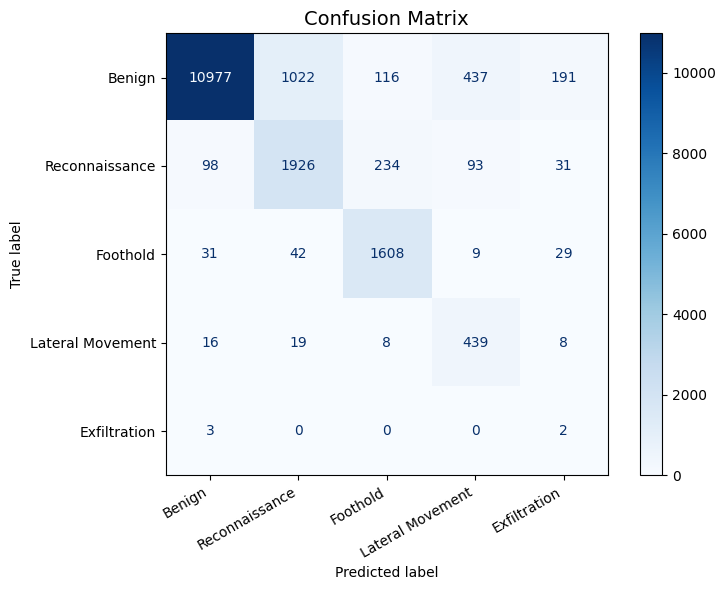

In [9]:
m = run_eval(model, test_loader)
print('\n===== TEST METRICS  =====')
print(f'Accuracy        : {m["acc"]:.4f}')
print(f'F1  (weighted)  : {m["f1"]:.4f}')
print(f'F1  (macro)     : {f1_score(m["true"], m["pred"], average="macro", zero_division=0):.4f}')
print(f'Precision (w)   : {m["prec"]:.4f}')
print(f'Recall    (w)   : {m["rec"]:.4f}')
print()
print(classification_report(m['true'], m['pred'],
                             target_names=APT_PHASE_NAMES, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix(m['true'], m['pred']),
    display_labels=APT_PHASE_NAMES
).plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Confusion Matrix', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('dapt2020_confusion_matrix.png', dpi=150)
plt.show()
